Interpretation of selected best models.

# Libraries

In [1]:
import os
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.inspection import permutation_importance

import shap

In [2]:
RANDOM_STATE = 42

In [3]:
# train/test split
import sys
sys.path.insert(1, '../utils_functionality/split_utils/')
from split_tools import get_train_test

In [4]:
# dict with num features
sys.path.insert(1, '../utils_functionality/models/')
from modelling2_hyperparams import dict_num_features

# Data folder

In [5]:
path_interpretations = Path('../results/best_models_interpretations_modelling_2/')
if not os.path.exists(path_interpretations): os.makedirs(path_interpretations)

# Models interpretation

../results/models_modelling_2/logisticregression_splashing_df_modelling_dimensionless_ordenc

In [6]:
target = 'splashing'
train, test = get_train_test(
    dataset_filename='df_modelling_dimensionless',
    target=target)
train = train[dict_num_features['df_modelling_dimensionless']+['wettability']+[target]]
test = test[dict_num_features['df_modelling_dimensionless']+['wettability']+[target]]

In [7]:
path_pipeline = r'../results/models_modelling_2/logisticregression_splashing_df_modelling_dimensionless_ordenc'
pipeline = joblib.load(path_pipeline)

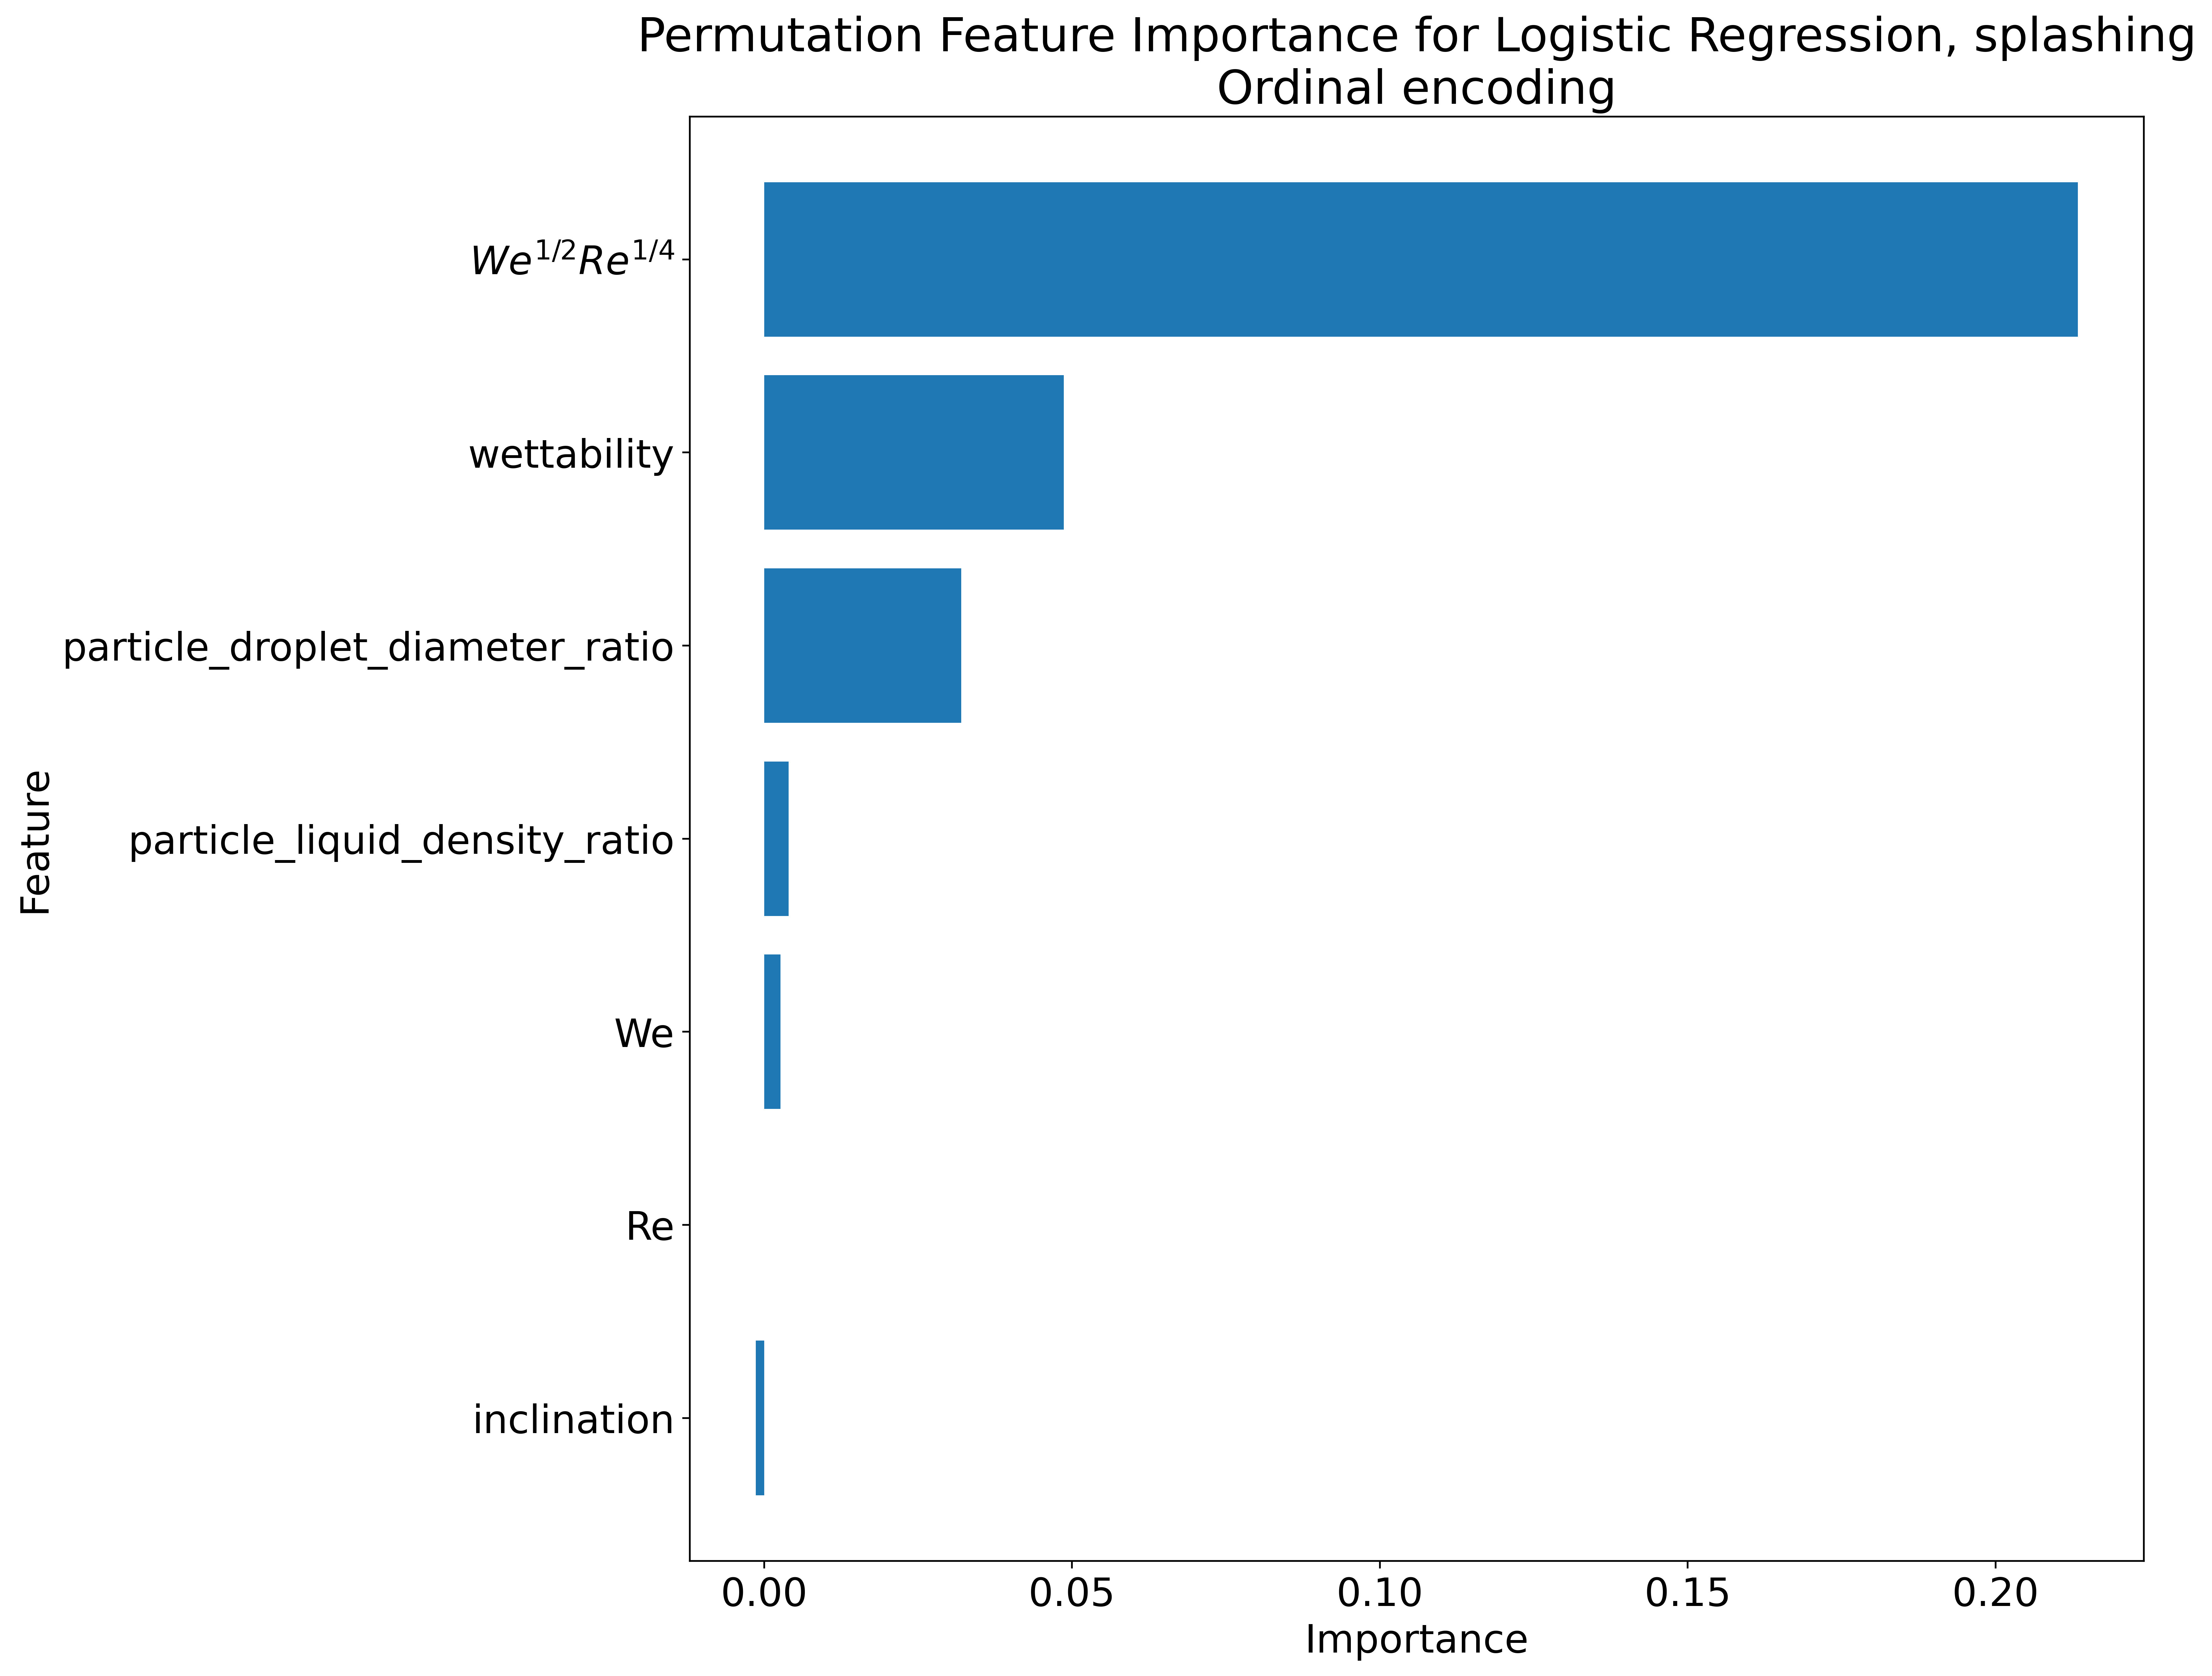

In [8]:
column_transformer = pipeline.steps[0][1].fit(train.drop(columns=[target]))
result = permutation_importance(
    estimator=pipeline.steps[1][1], 
    X=column_transformer.transform(test.drop(columns=[target])), 
    y=test[target], 
    n_repeats=20, 
    random_state=RANDOM_STATE)

importances = result.importances_mean
feature_names = column_transformer.get_feature_names_out()
feature_names = [x.split('__')[1] for x in feature_names]

df_permut_feature_importance = pd.DataFrame(
    {'Feature name': feature_names, 
     'Feature importance': importances}
).sort_values(by='Feature importance')

plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(12, 12),dpi=500)
plt.barh(
    y=df_permut_feature_importance['Feature name'].replace('We_Re', '$We^{1/2}Re^{1/4}$'),
    width=df_permut_feature_importance['Feature importance']
    )
plt.xlabel('Importance', fontsize=18)
plt.ylabel('Feature', fontsize=18)
plt.title(f'Permutation Feature Importance for Logistic Regression, {target}\nOrdinal encoding')
plt.savefig(path_interpretations / f'logisticregression_splashing_df_modelling_dimensionless_ordenc.pdf', bbox_inches='tight')
plt.show()

../results/models_modelling_2/logisticregression_net_impact_df_modelling_dimensionless_ordenc

In [9]:
target = 'net_impact'
train, test = get_train_test(
    dataset_filename='df_modelling_dimensionless',
    target=target)
train = train[dict_num_features['df_modelling_dimensionless']+['wettability']+[target]]
test = test[dict_num_features['df_modelling_dimensionless']+['wettability']+[target]]

In [10]:
path_pipeline = '../results/models_modelling_2/logisticregression_net_impact_df_modelling_dimensionless_ordenc'
pipeline = joblib.load(path_pipeline)

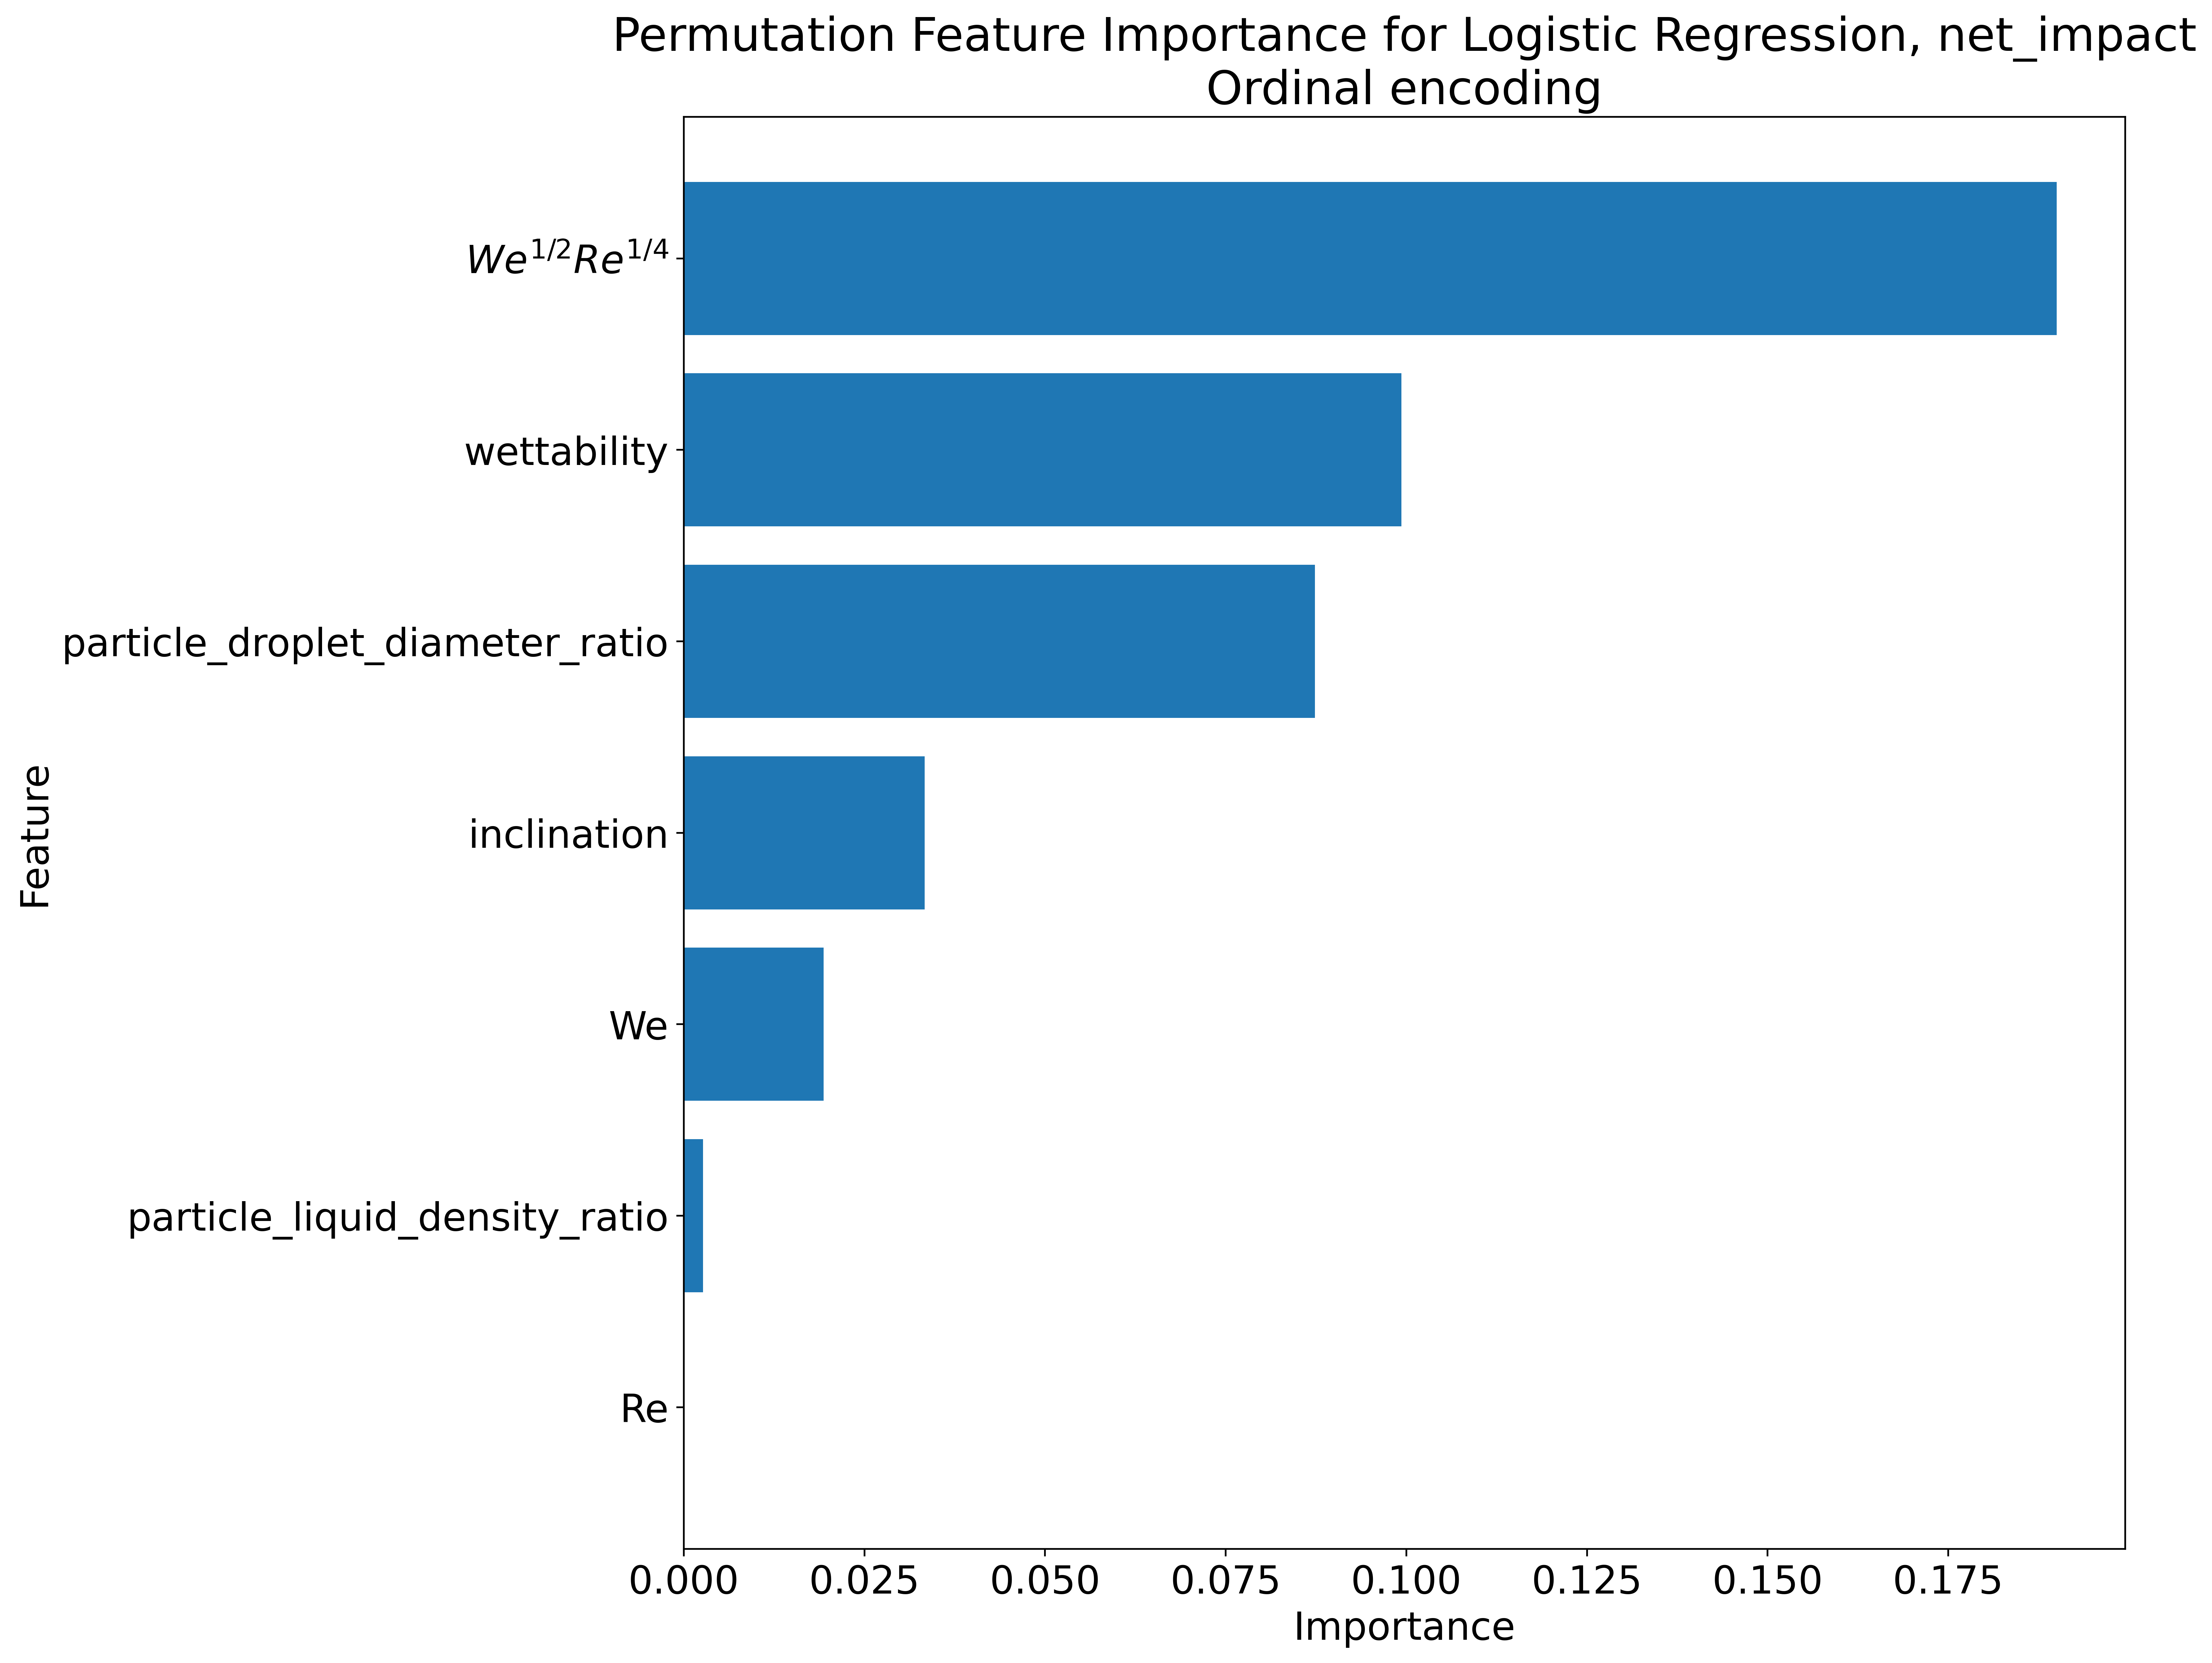

In [11]:
column_transformer = pipeline.steps[0][1].fit(train.drop(columns=[target]))
result = permutation_importance(
    estimator=pipeline.steps[1][1], 
    X=column_transformer.transform(test.drop(columns=[target])), 
    y=test[target], 
    n_repeats=20, 
    random_state=RANDOM_STATE)

importances = result.importances_mean
feature_names = column_transformer.get_feature_names_out()
feature_names = [x.split('__')[1] for x in feature_names]

df_permut_feature_importance = pd.DataFrame(
    {'Feature name': feature_names, 
     'Feature importance': importances}
).sort_values(by='Feature importance')

plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(12, 12),dpi=500)
plt.barh(
    y=df_permut_feature_importance['Feature name'].replace('We_Re', '$We^{1/2}Re^{1/4}$'),
    width=df_permut_feature_importance['Feature importance']
    )
plt.xlabel('Importance', fontsize=18)
plt.ylabel('Feature', fontsize=18)
plt.title(f'Permutation Feature Importance for Logistic Regression, {target}\nOrdinal encoding')
plt.savefig(path_interpretations / f'logisticregression_net_impact_df_modelling_dimensionless_ordenc.pdf', bbox_inches='tight')
plt.show()

../results/models_modelling_2/catboostclassifier_splashing_df_modelling_dimensionless

In [13]:
path_pipeline = '../results/models_modelling_2/catboostclassifier_splashing_df_modelling_dimensionless'
pipeline = joblib.load(path_pipeline)

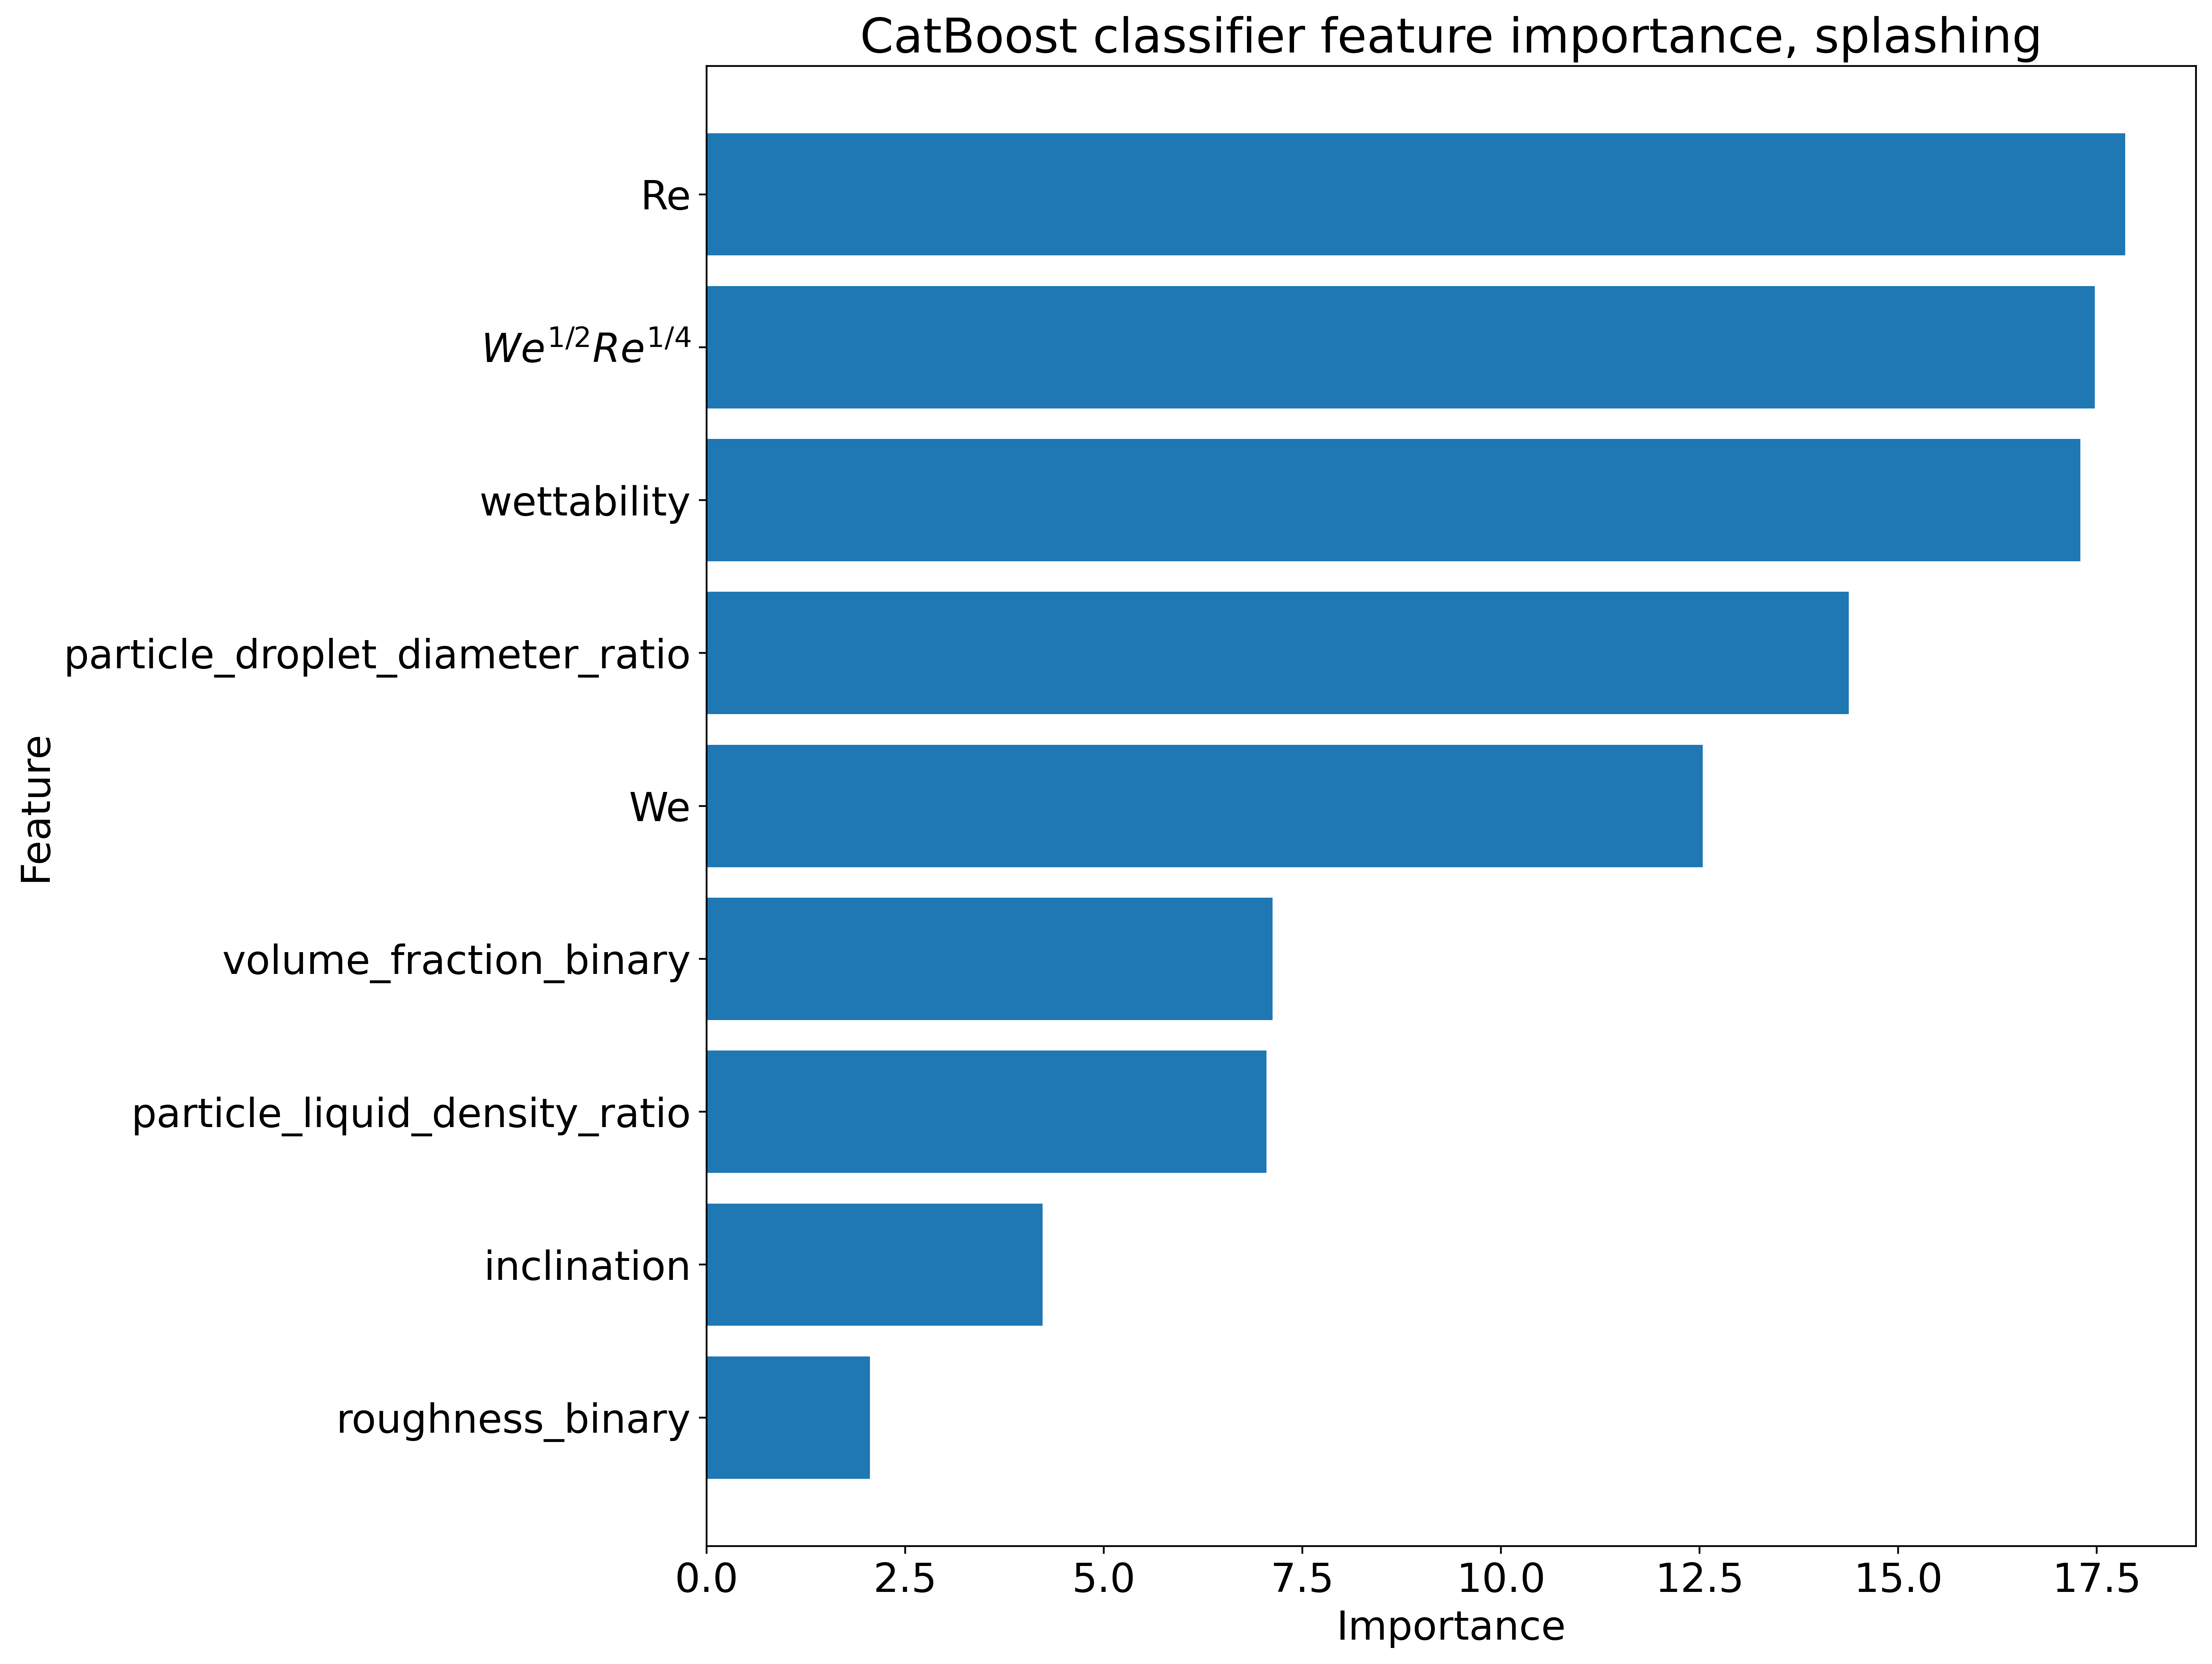

In [14]:
importances = pipeline.steps[0][1].feature_importances_
feature_names = pipeline.steps[0][1].feature_names_

df_permut_feature_importance = pd.DataFrame(
    {'Feature name': feature_names, 
     'Feature importance': importances}
).sort_values(by='Feature importance')

plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(12, 12),dpi=500)
plt.barh(
    y=df_permut_feature_importance['Feature name'].replace('We_Re', '$We^{1/2}Re^{1/4}$'),
    width=df_permut_feature_importance['Feature importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title(f'CatBoost classifier feature importance, {target}')

plt.savefig(path_interpretations / f'catboostclassifier_splashing_df_modelling_dimensionless.pdf', bbox_inches='tight')
plt.show()

In [47]:
target = 'splashing'
train, test = get_train_test(
    dataset_filename='df_modelling_dimensionless',
    target=target)
train = train[feature_names+[target]]
test = test[feature_names+[target]]

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


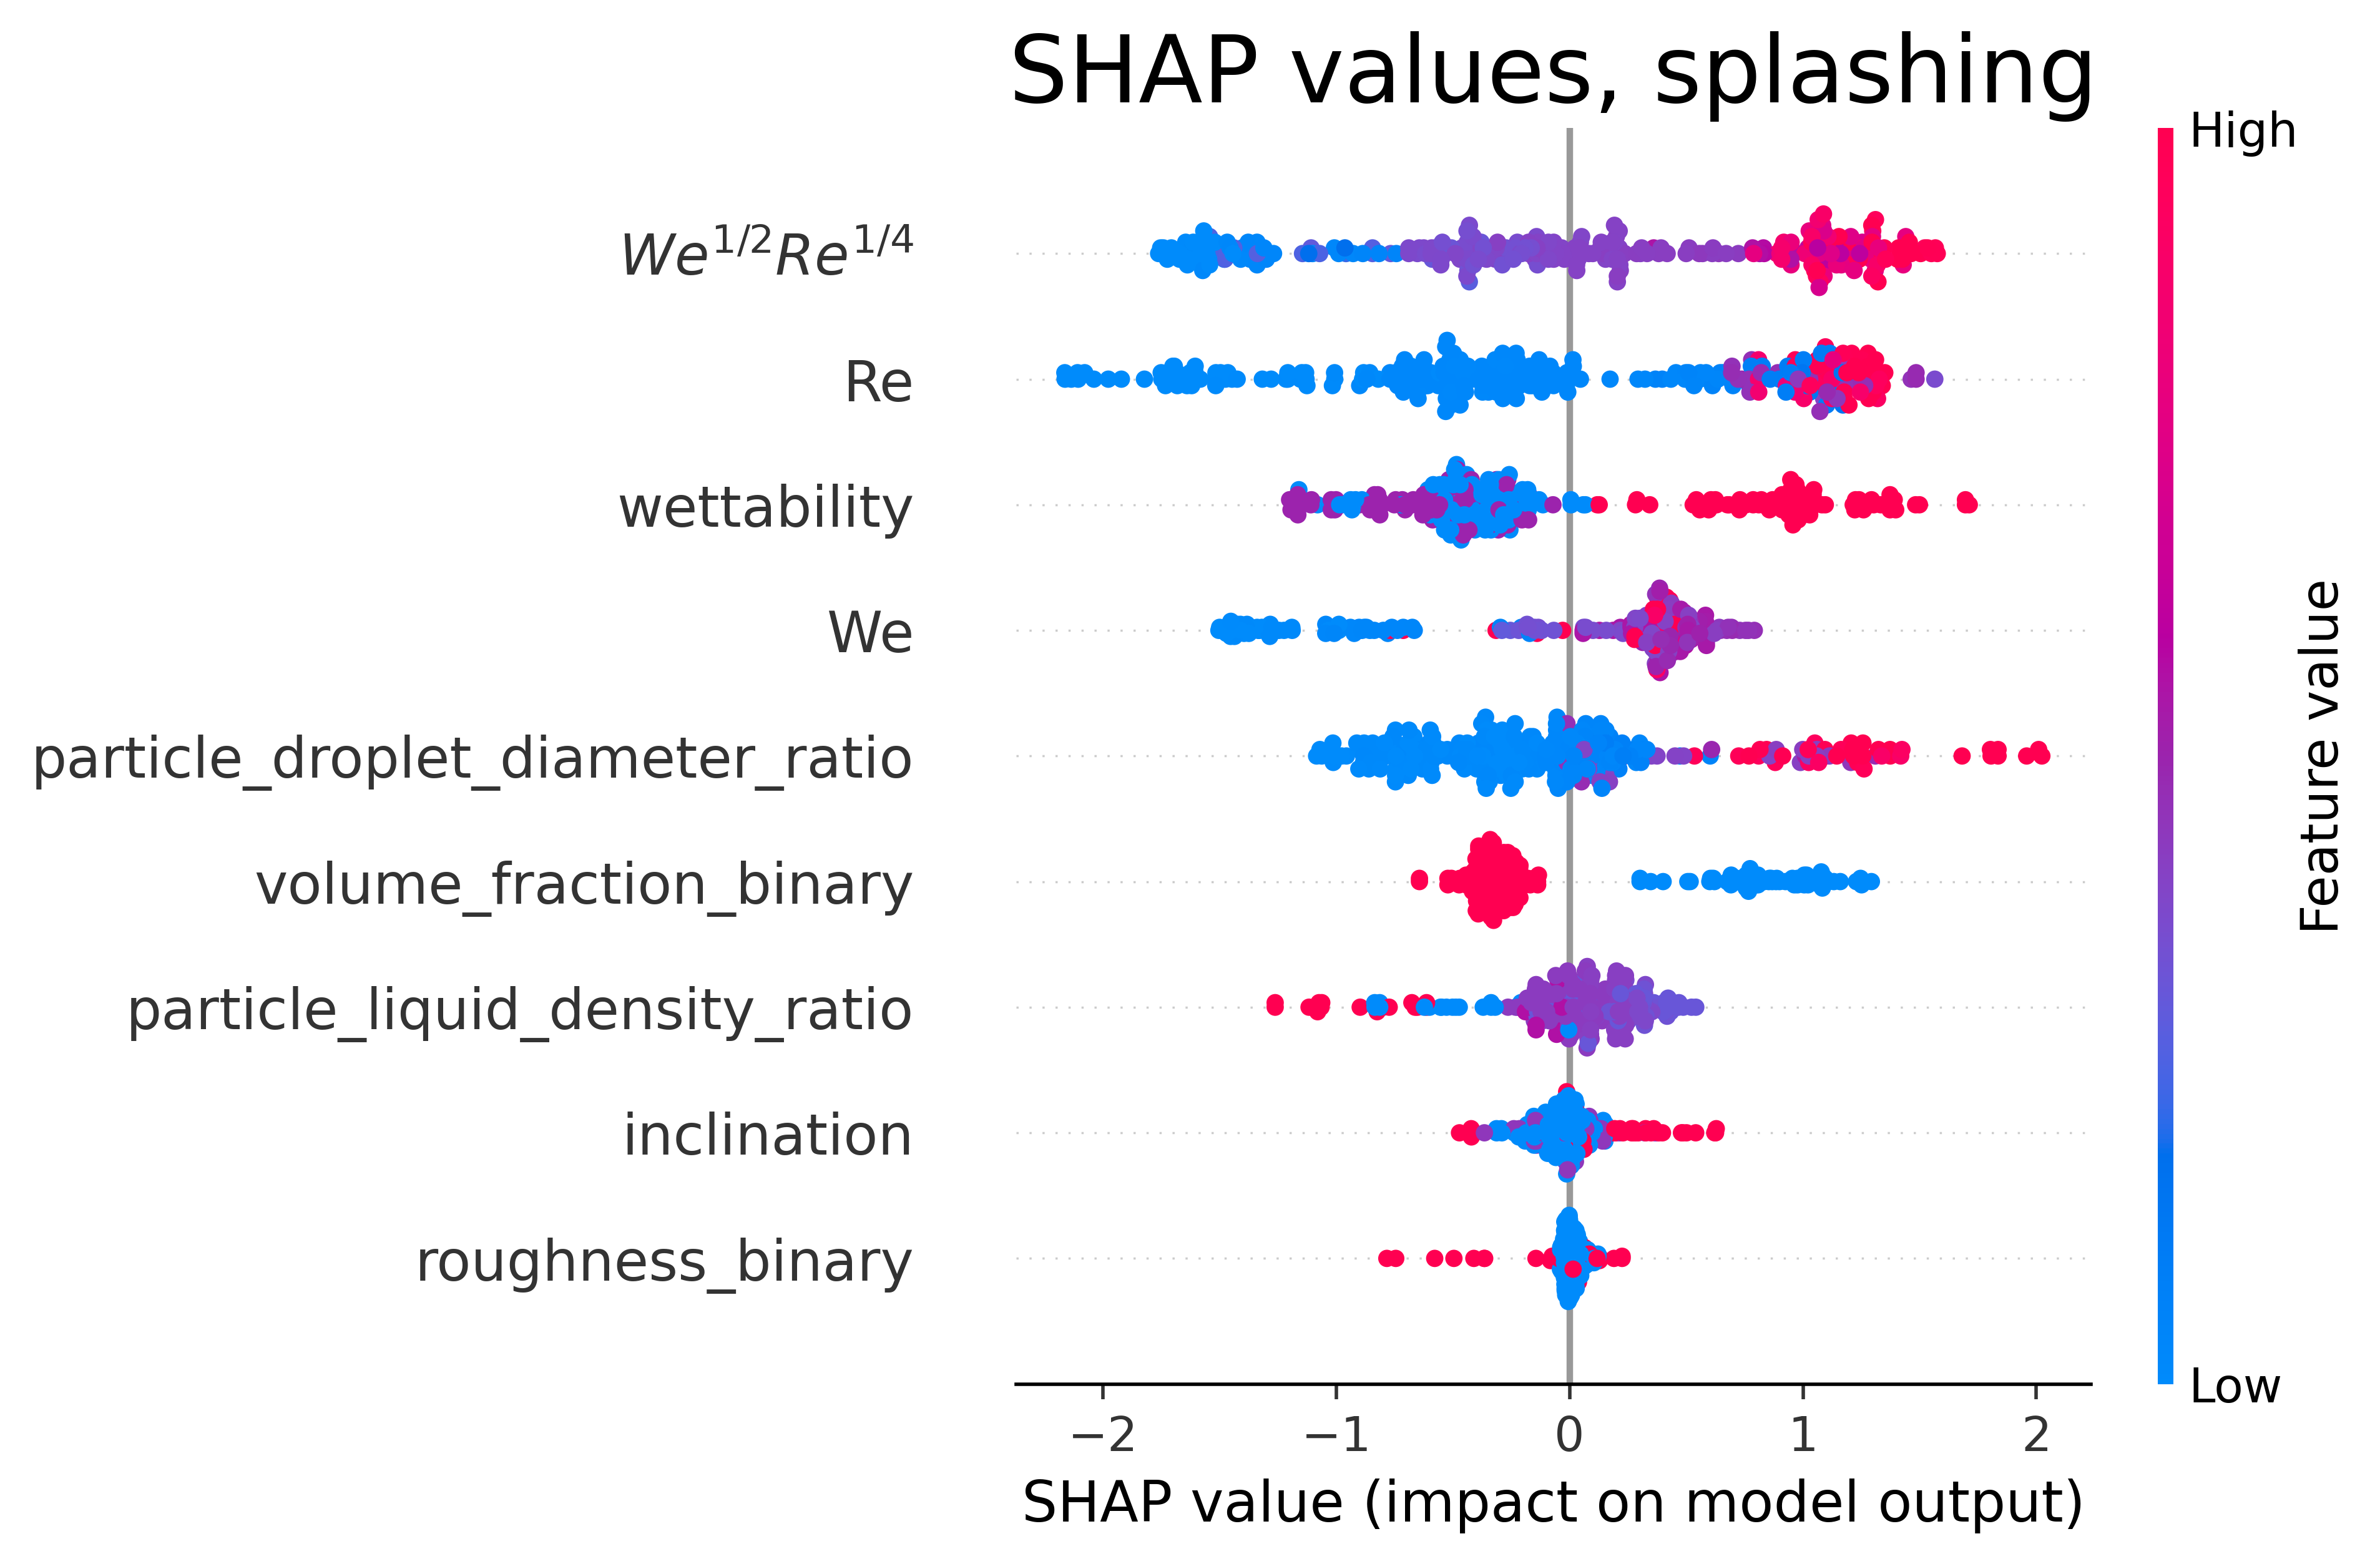

In [100]:
X = train.drop(columns=[target])
shap_fnames = {x: x for x in feature_names}
shap_fnames['We_Re'] = r"$We^{1/2}Re^{1/4}$"
shap_fnames = list(shap_fnames.values())
model = pipeline.steps[0][1]
explainer = shap.TreeExplainer(model)
shap_values = explainer(X)
plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(12, 12),dpi=500)
shap.summary_plot(shap_values, X, feature_names=shap_fnames, show=False)
plt.title('SHAP values, splashing')
plt.savefig(path_interpretations / f'catboostclassifier_splashing_df_modelling_dimensionless_shap.pdf', bbox_inches='tight')
plt.show()

../results/models_modelling_2/catboostclassifier_net_impact_df_modelling_dimensionless

In [102]:
path_pipeline = '../results/models_modelling_2/catboostclassifier_net_impact_df_modelling_dimensionless'
pipeline = joblib.load(path_pipeline)

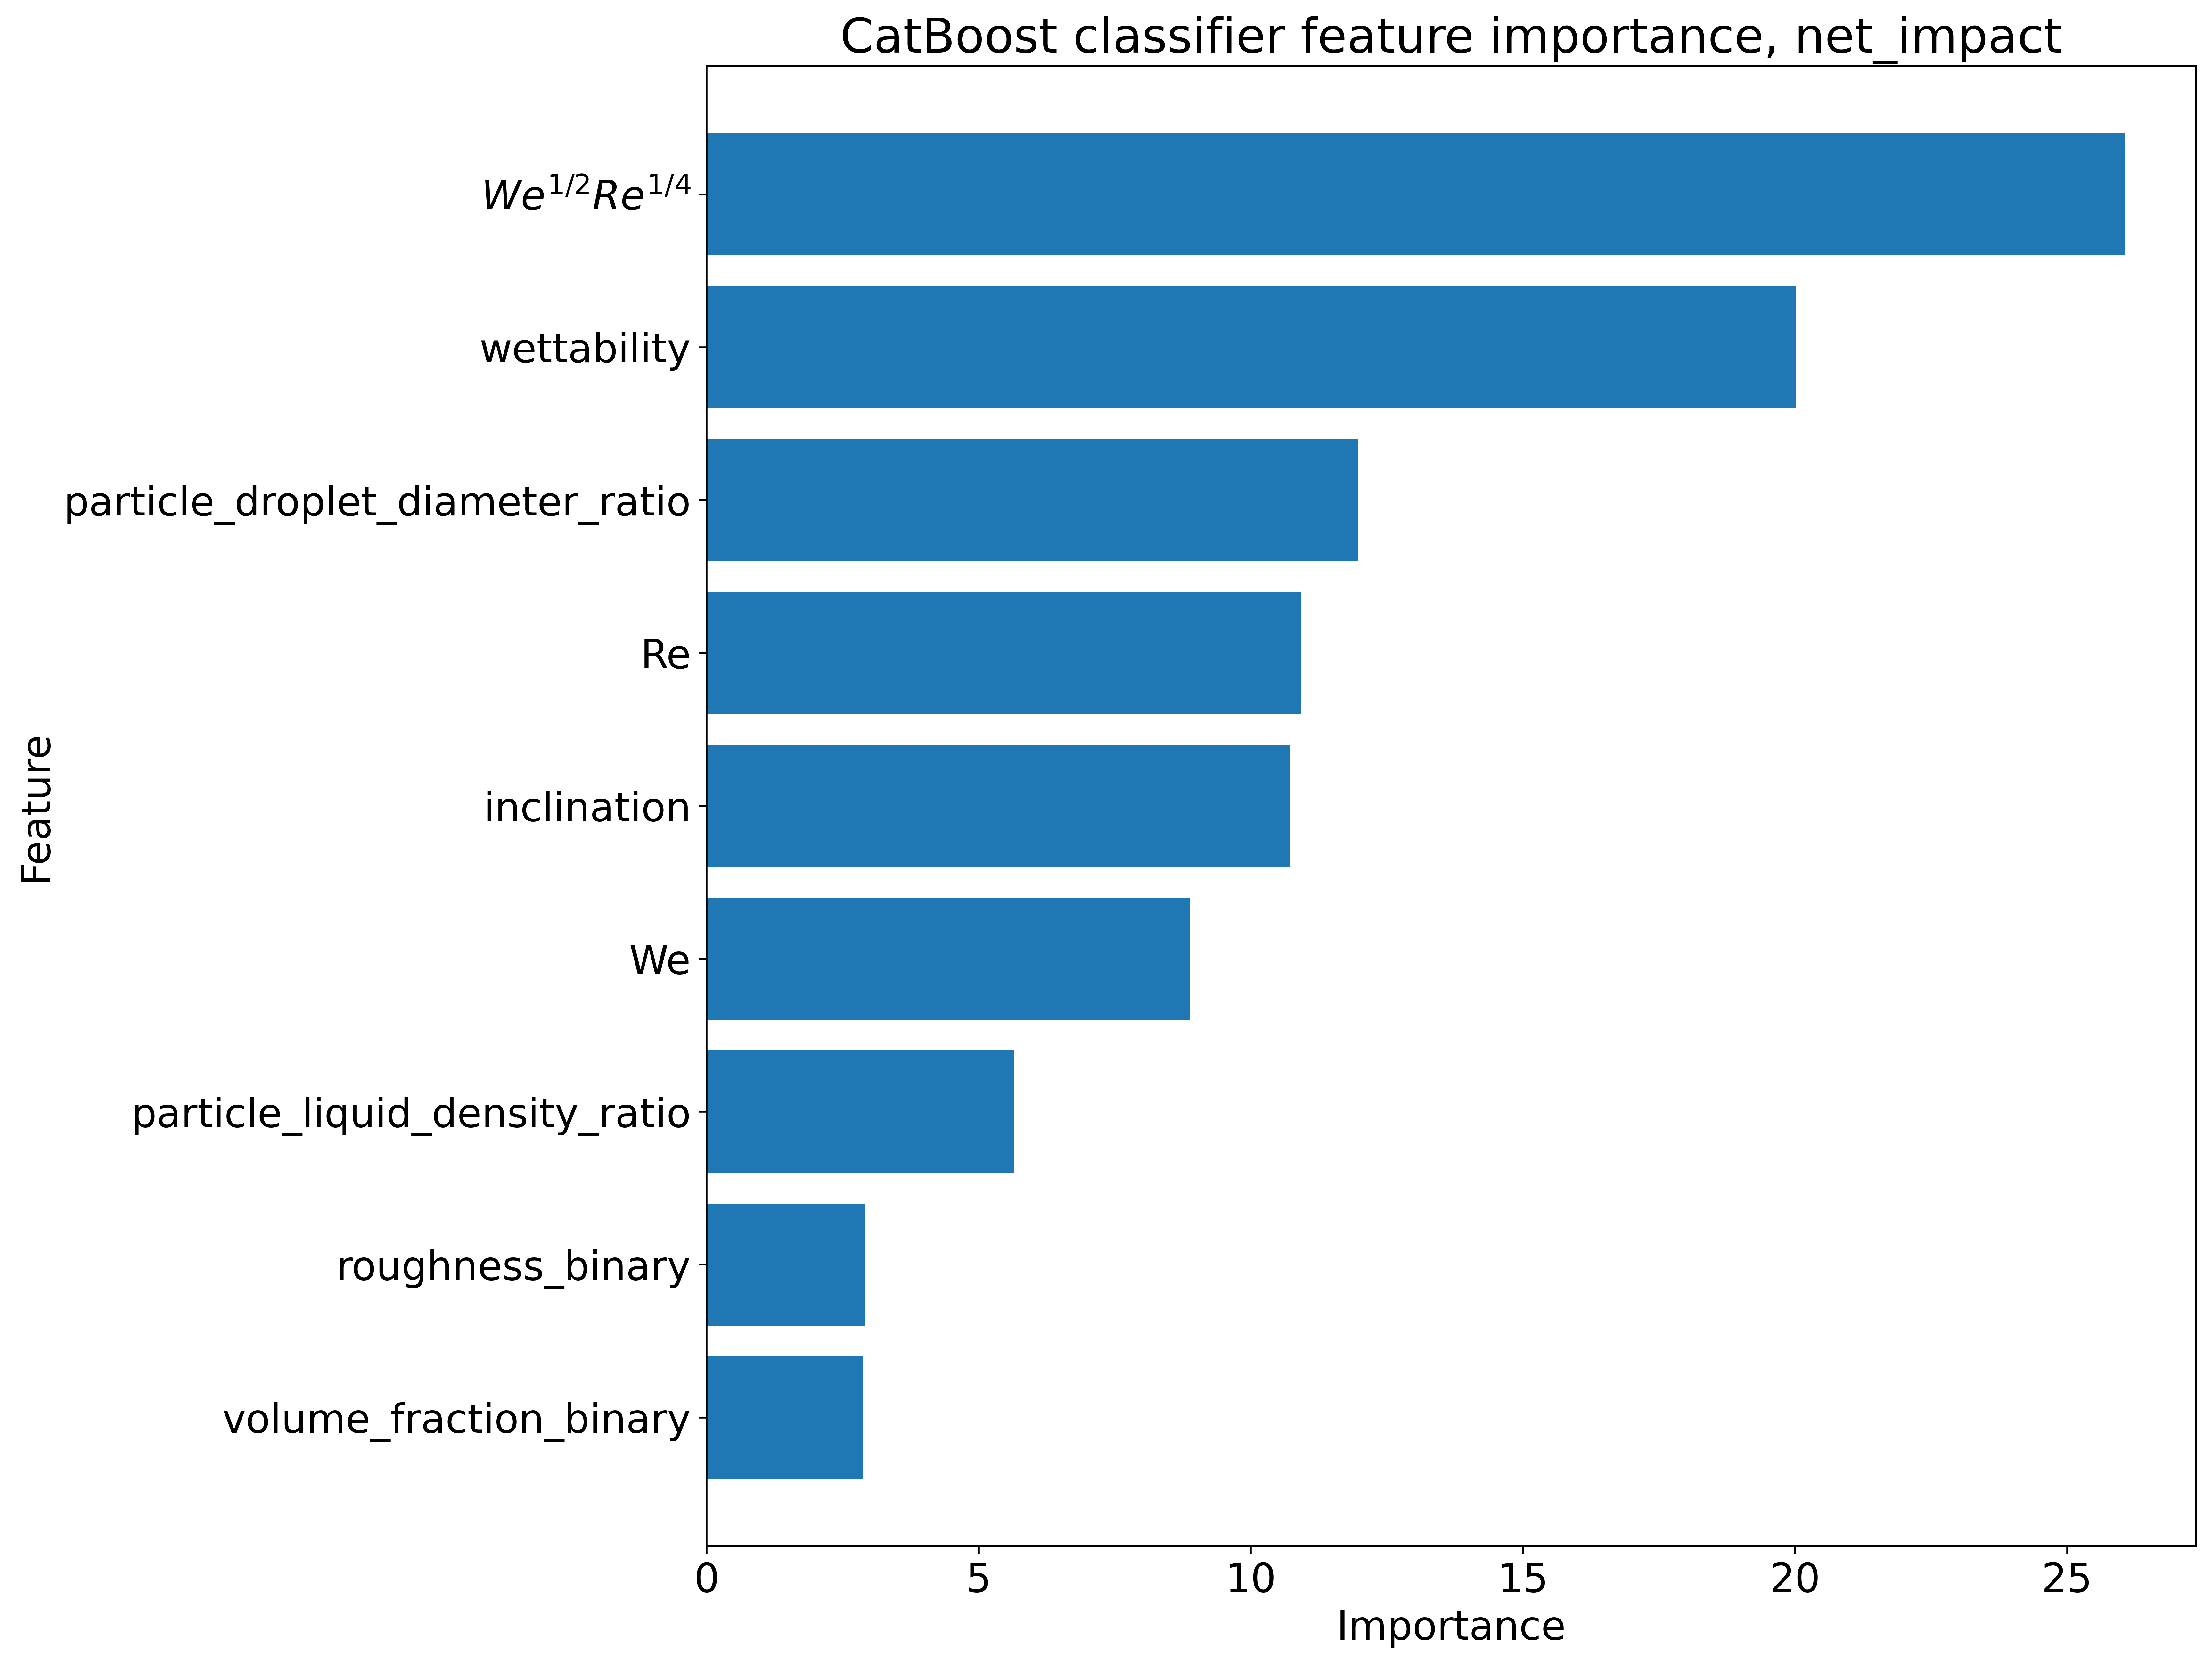

In [103]:
importances = pipeline.steps[0][1].feature_importances_
feature_names = pipeline.steps[0][1].feature_names_

df_permut_feature_importance = pd.DataFrame(
    {'Feature name': feature_names, 
     'Feature importance': importances}
).sort_values(by='Feature importance')

plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(12, 12),dpi=500)
plt.barh(
    y=df_permut_feature_importance['Feature name'].replace('We_Re', '$We^{1/2}Re^{1/4}$'),
    width=df_permut_feature_importance['Feature importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title(f'CatBoost classifier feature importance, net_impact')

plt.savefig(path_interpretations / f'catboostclassifier_net_impact_df_modelling_dimensionless.pdf', bbox_inches='tight')
plt.show()

In [108]:
target = 'net_impact'
train, test = get_train_test(
    dataset_filename='df_modelling_dimensionless',
    target=target)
train = train[feature_names+[target]]
test = test[feature_names+[target]]

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


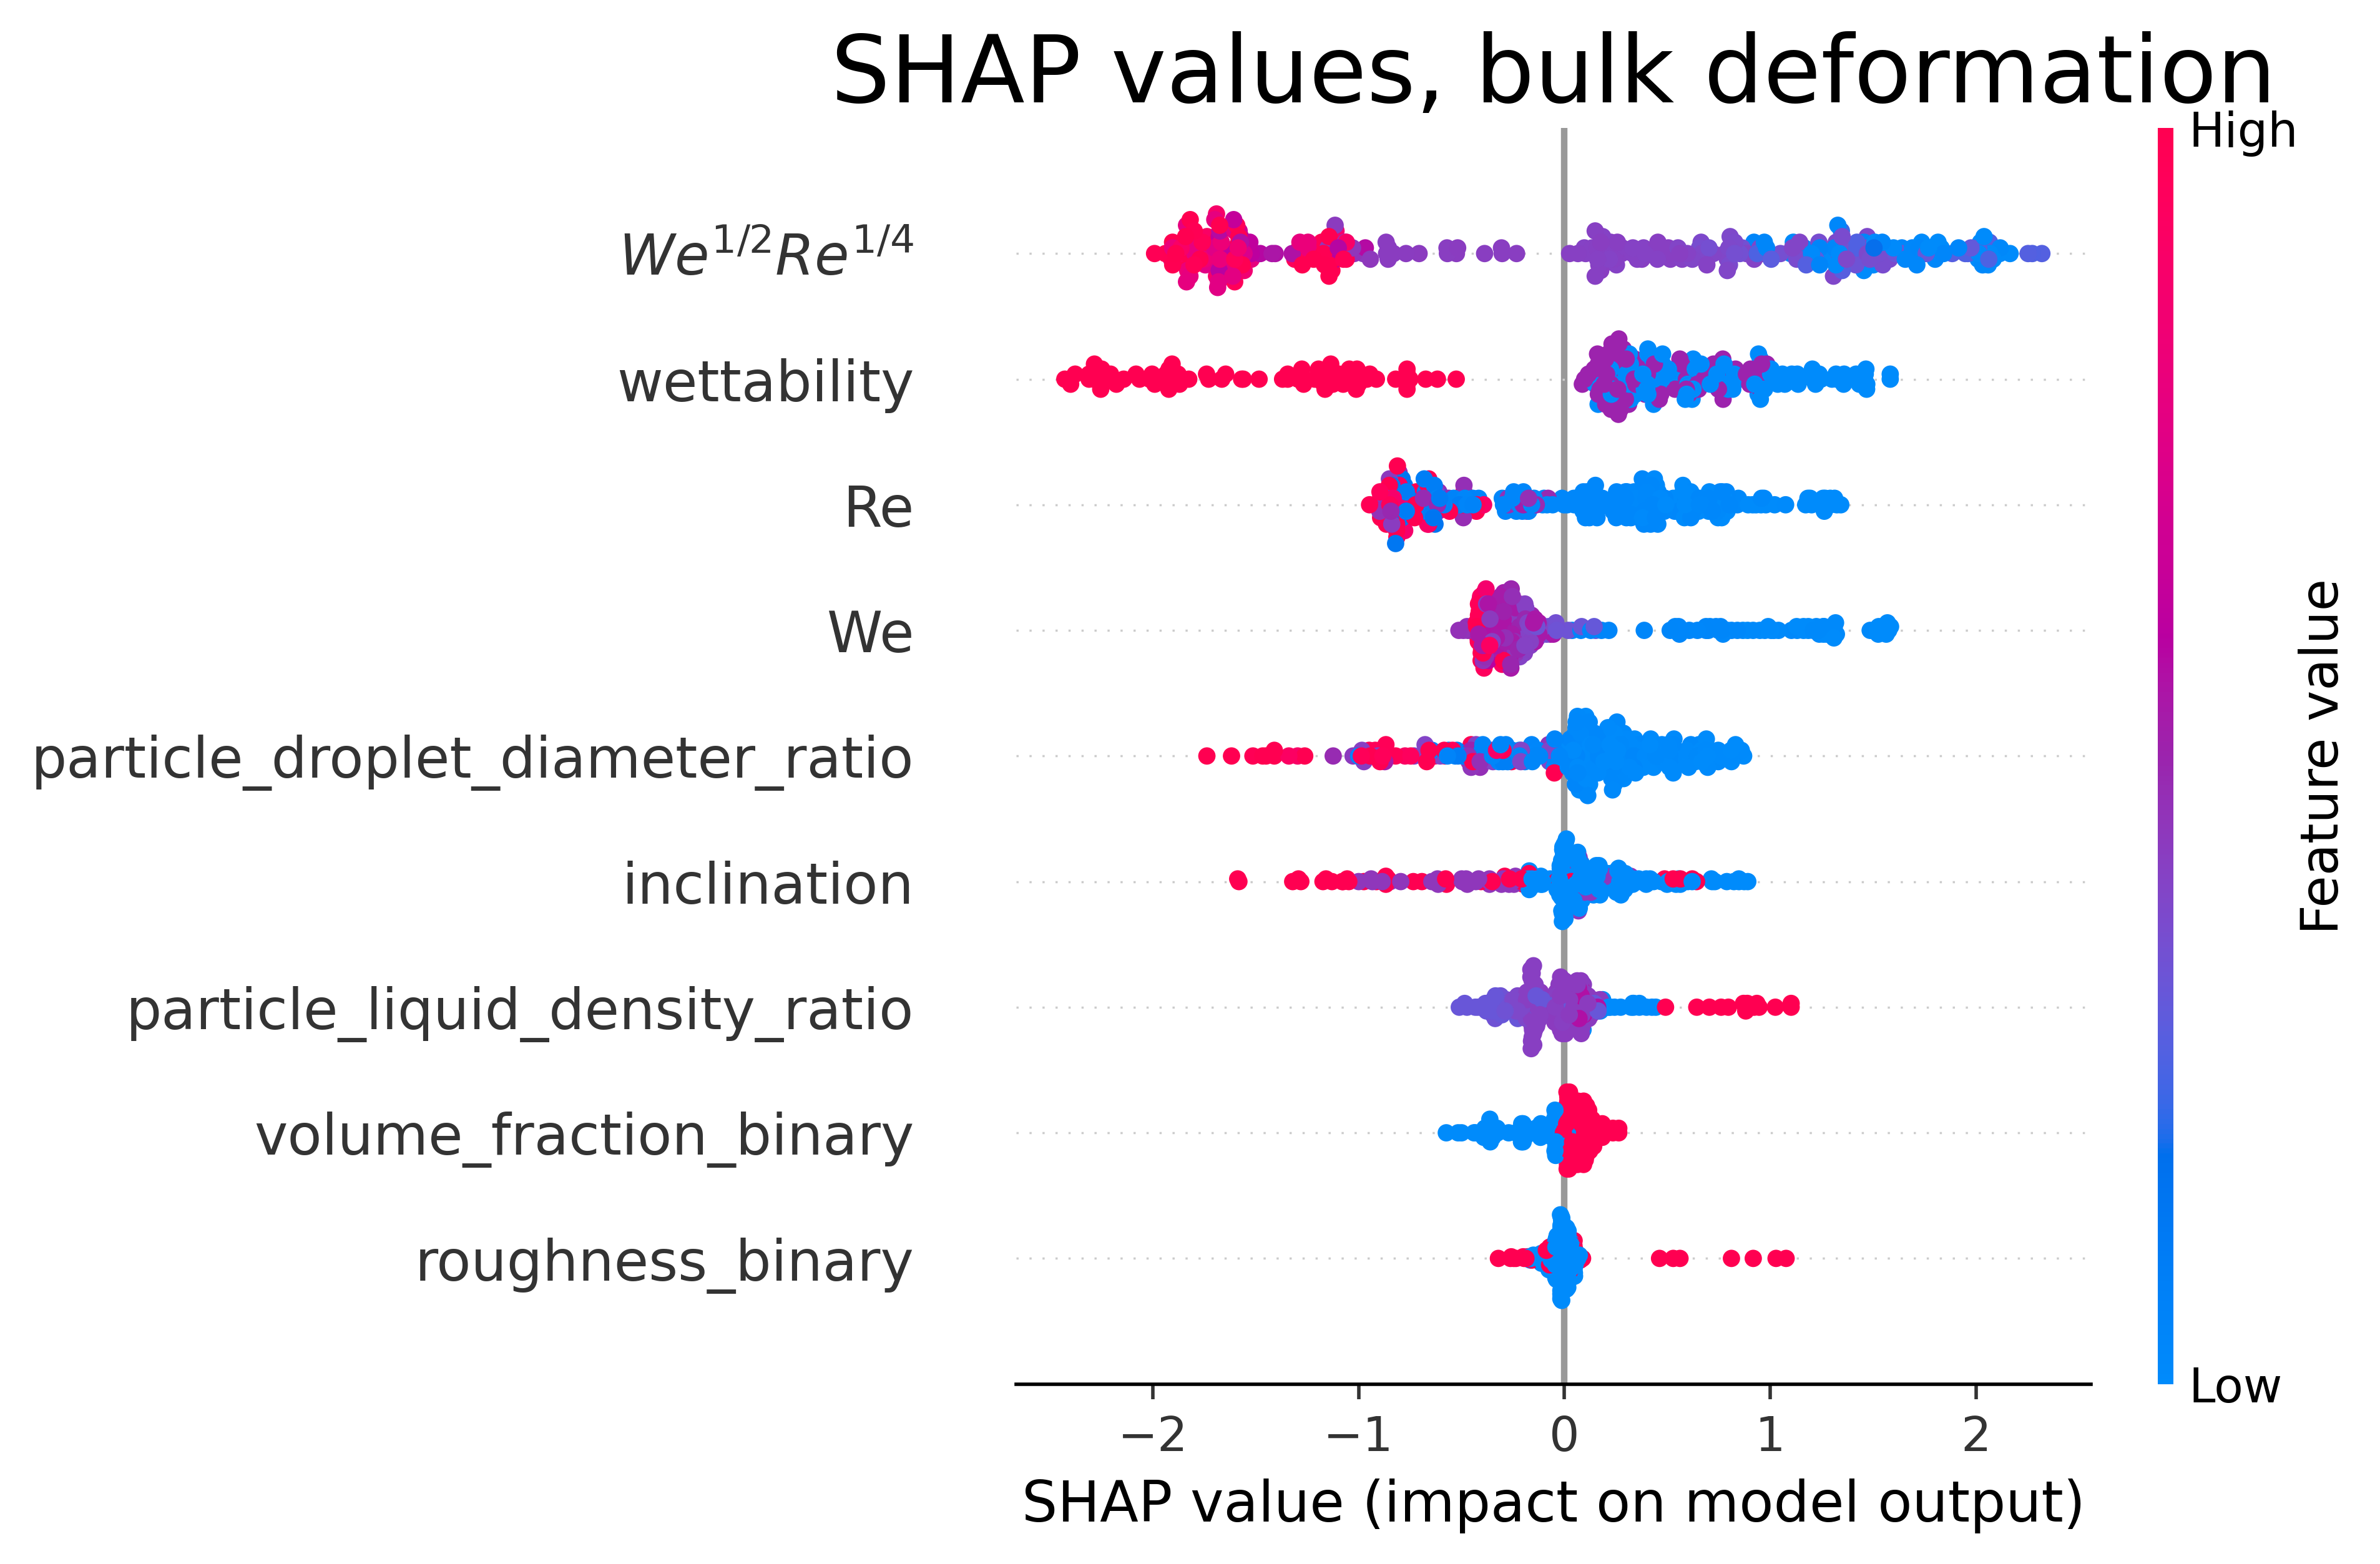

In [109]:
X = train.drop(columns=[target])
shap_fnames = {x: x for x in feature_names}
shap_fnames['We_Re'] = r"$We^{1/2}Re^{1/4}$"
shap_fnames = list(shap_fnames.values())
model = pipeline.steps[0][1]
explainer = shap.TreeExplainer(model)
shap_values = explainer(X)
plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(12, 12),dpi=500)
shap.summary_plot(shap_values, X, feature_names=shap_fnames, show=False)
plt.title('SHAP values, bulk deformation')
plt.savefig(path_interpretations / f'catboostclassifier_bulk_deformation_df_modelling_dimensionless_shap.pdf', bbox_inches='tight')
plt.show()